<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/main/week10_%EC%8B%9C%EA%B3%84%EC%97%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7장 시계열 분석

데이터 변동 유형에 따라

* 불규칙 변동: 시간에 따른 규칙적인 움직임과 달리 어떤
규칙성이 없어 예측 불가능하고 우연적으로 발생하는 변동
* 추세 변동: 시계열 자료가 갖는 장기적인 변화 추세
* 순환 변동: 2-3년 정도의 일정 기간을 주기로 순환적으로 나타나는 변동(경기 변동)
* 계절 변동:  계절적 영향과 사회적 관습에 따라 1년
주기로 발생

시계열 데이터를 잘 분석한다는 것은 불규칙성을 갖는 시계열 데이터에 특정한 기법
이나 모벨을 적용하여 규칙적 패턴을 찾거나 예측히는 것을 의미

 불규칙적 시계열 데이터
에 규칙성을 부여하는 방법으로는 AR. MA. ARMA. ARIMA 모벨을 적용하는 것이 가장 널리 알
려져 있습니다. 하지만 최근에는 답러닝을 이용하여 시계열 데이터의 연속성을 기계 스스로 찾아
내도록 하는 방법이 더 좋은 성능을 내고 있습니다.

## 7.2 AR, MA, ARMA, ARIMA

* AR 모델:이전 관측값이 이후 관측 값에 영향을 준다는 아이디어(자기 회귀 모델)

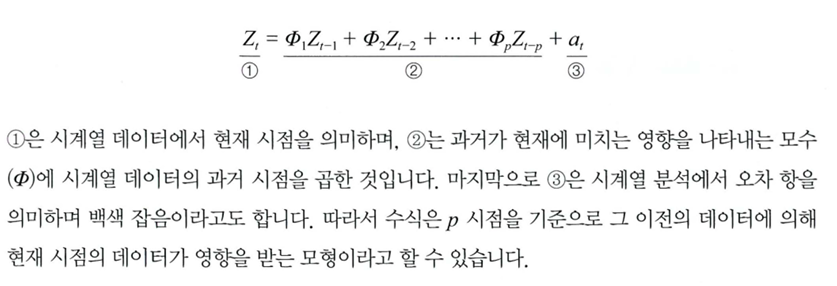

* MA 모델: 트렌드가 변화하는 상화에 적합한 회귀 모델/ 시계열을 따라 윈도우 크기만큼 슬라이딩된다고 하여 이동평균모델이라고 함

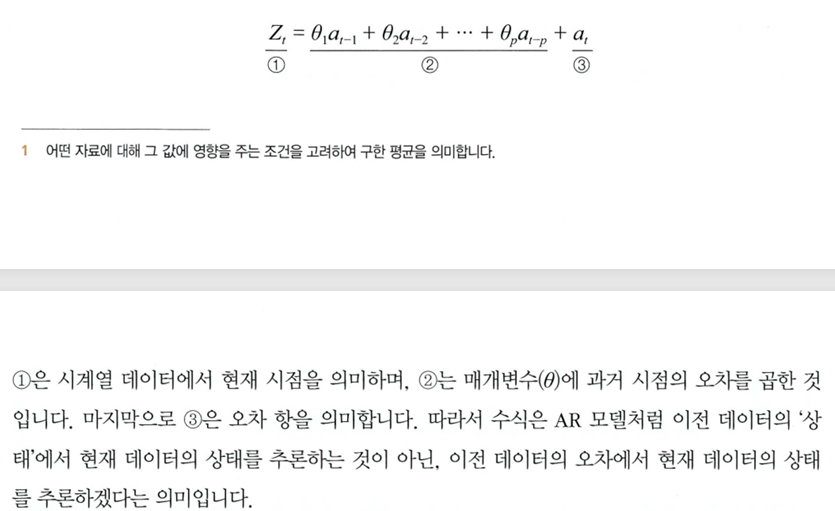

* ARMA 모델

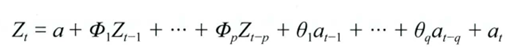

* ARIMA 모델:  자기 회귀와
이동평균을둘다고려하는모형인데 ARMA와달리 과거 데이터의 선형 관계뿐만아니라추세고려

In [1]:
! pip install statsmodels

/tmp/ipykernel_13971/1715707885.py:9: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series=read_csv('sales.csv', header = 0, parse_dates = [0], index_col = 0, date_parser=parser)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Fri, 08 May 2026   AIC                            411.302
Time:                        06:19:12   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

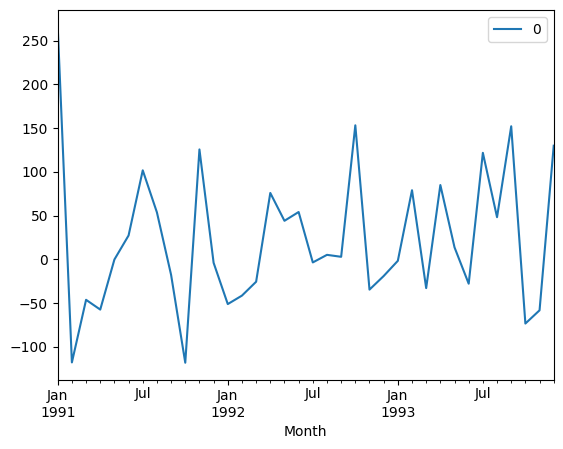

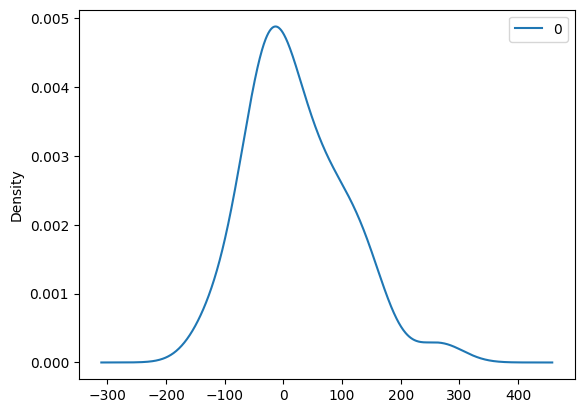

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [5]:
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):
  return datetime.strptime('199'+x,'%Y-%m')
series=read_csv('sales.csv', header = 0, parse_dates = [0], index_col = 0, date_parser=parser)
model=ARIMA(series,order=(5,1,0))
model_fit=model.fit()
print(model_fit.summary())
residuals=DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

/tmp/ipykernel_13971/2350350069.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f,expected=%f'%(yhat,obs))


predicted=352.855343,expected=346.300000
predicted=277.398036,expected=329.700000
predicted=368.753734,expected=445.400000
predicted=331.773635,expected=325.900000
predicted=372.070407,expected=449.300000
predicted=360.020872,expected=411.300000
predicted=454.526230,expected=417.400000
predicted=388.690699,expected=545.500000
predicted=437.632447,expected=477.600000
predicted=516.437624,expected=687.000000
predicted=520.916191,expected=435.300000
predicted=675.594647,expected=587.300000
predicted=505.201016,expected=676.900000
Test MSE: 9118.818


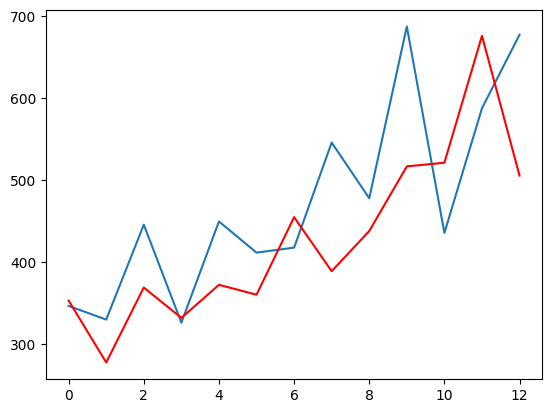

In [9]:
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
  return datetime.strptime('199'+x,'%Y-%m')
X=series.values
X=np.nan_to_num(X)
size=int(len(X)*0.66)
train,test=X[0:size],X[size:len(X)]
history=[x for x in train]
predictions=list()
for t in range(len(test)):
  model=ARIMA(history, order=(5,1,0))
  model_fit=model.fit()
  output=model_fit.forecast()
  yhat=output[0]
  predictions.append(yhat)
  obs=test[t]
  history.append(obs)
  print('predicted=%f,expected=%f'%(yhat,obs))
error=mean_squared_error(test,predictions)
print('Test MSE: %.3f'%error)
pyplot.plot(test)
pyplot.plot(predictions,color='red')
pyplot.show()



# 7.3 순환 신경망(RNN)

시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신
경망

.RNN이 기존 네트워크와 다른 점은 ‘기억을 가짐

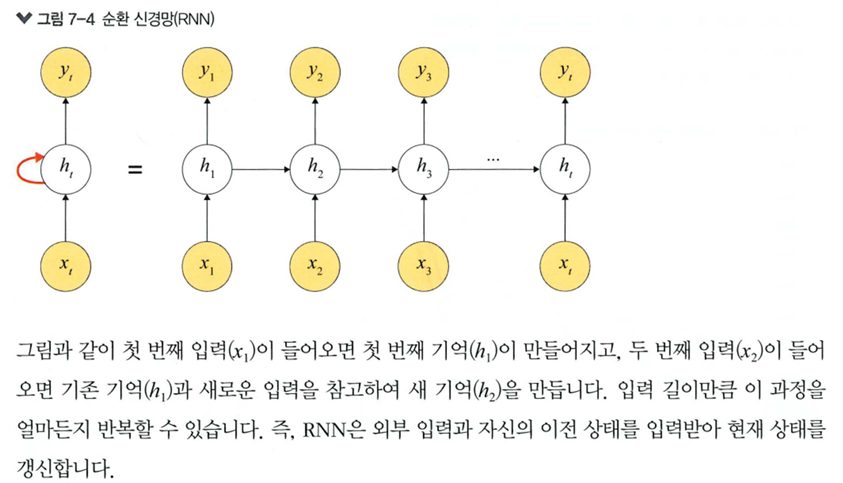

1. 일대일: 순환이 없기 때문에 RNN이라고 말하기 어려우며， 순방향 네트워크가 대표적 사례입
니다.
2. 일대다: 입력이 하나이고， 출력이 다수인 구조입니다. 이미지를 입력해서 이미지에 대한 설명
을 문장으로 출력하는 이미지 캡션(image cartioning)이 대표적 사례입니다.
3. 다대일: 입력이 다수이고 출력이 하나인 구조로 문장을 입력해서 긍정/부정을 출력히는 감성
분석기에서 사용됩니다.

4. 다대다: 입력과출력이 다수인 구조로 언어를 번역하는자동 번역기 등이 대표적인 사례입나다.

5. 동기화 다대다: 4의 유형처럼 입력과 출력이 다수인 구조입니다. 문장에서 다옴에 나올 단어를
예측하는언어 모댈 즉프레임 수준의 비디오분류가대표적 사례입니다.

* RNN 계층과 셀

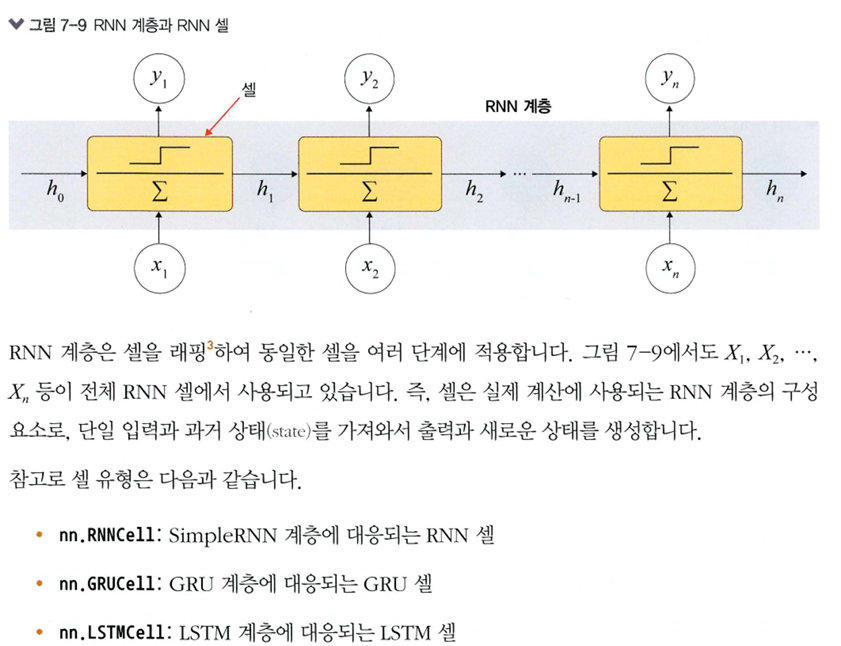

# 문자단위 RNN

RNN의 입출력의 단위가 단어 레벨(word-level)이 아니라 문자 레벨(character-level)로 하여 RNN을 구현한다면, 이를 문자 단위 RNN이라고 합니다. RNN 구조 자체가 달라진 것은 아니고, 입, 출력의 단위가 문자로 바뀌었을 뿐입니다. 문자 단위 RNN을 다대다 구조로 구현해봅시다.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

1) 훈련 데이터 전처리하기
여기서는 문자 시퀀스 apple을 입력받으면 pple!를 출력하는 RNN을 구현해볼 겁니다. 이렇게 구현하는 어떤 의미가 있지는 않습니다. 그저 RNN의 동작을 이해하기 위한 목적입니다.

입력 데이터와 레이블 데이터에 대해서 문자 집합(voabulary)을 만듭니다. 여기서 문자 집합은 중복을 제거한 문자들의 집합입니다.

In [11]:
input_str='apple'
label_str='pple!'
char_vocab=sorted(list(set(input_str+label_str)))
vocab_size=len(char_vocab)
print('문자 집합의 크기 : {}'.format(vocab_size))

문자 집합의 크기 : 5


현재 문자 집합에는 총 5개의 문자가 있습니다. !, a, e, l, p입니다. 이제 하이퍼파라미터를 정의해줍니다. 이때 입력은 원-핫 벡터를 사용할 것이므로 입력의 크기는 문자 집합의 크기여야만 합니다.

In [22]:
input_size=vocab_size
hidden_size=5
output_size=5
learning_rate=0.1

In [13]:
char_to_index=dict((c,i) for i,c in enumerate(char_vocab))
print(char_to_index)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


!은 0, a는 1, e는 2, l은 3, p는 4가 부여되었습니다. 나중에 예측 결과를 다시 문자 시퀀스로 보기위해서 반대로 정수로부터 문자를 얻을 수 있는 index_to_char을 만듭니다.

In [14]:
index_to_char={}
for key, value in char_to_index.items():
  index_to_char[value]=key
print(index_to_char)


{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [15]:
x_data=[char_to_index[c] for c in input_str]
y_data=[char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


파이토치의 nn.RNN()은 기본적으로 3차원 텐서를 입력받습니다. 그렇기 때문에 배치 차원을 추가해줍니다.

In [16]:
x_data=[x_data]
y_data=[y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [17]:
x_one_hot=[np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)

[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [18]:
X=torch.FloatTensor(x_one_hot)
Y=torch.LongTensor(y_data)

/tmp/ipykernel_13971/992893729.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X=torch.FloatTensor(x_one_hot)


In [19]:
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기 : {}'.format(Y.shape))


훈련 데이터의 크기: torch.Size([1, 5, 5])
레이블의 크기 : torch.Size([1, 5])


2) 모델 구현하기  

이제 RNN 모델을 구현해봅시다. 아래에서 fc는 완전 연결층(fully-connected layer)을 의미하며 출력층으로 사용됩니다.

In [20]:
class Net(torch.nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super(Net,self).__init__()
    self.rnn=torch.nn.RNN(input_size,hidden_size,batch_first=True)
    self.fc=torch.nn.Linear(hidden_size,output_size,bias=True)
  def forward(self,x):
    x,_status=self.rnn(x)
    x=self.fc(x)
    return x

In [23]:
net=Net(input_size,hidden_size,output_size)

In [24]:
outputs=net(X)
print(outputs.shape)

torch.Size([1, 5, 5])


In [26]:
print(outputs.view(-1,input_size).shape)

torch.Size([5, 5])


In [28]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


레이블 데이터는 (1, 5)의 크기를 가지는데, 마찬가지로 나중에 정확도를 측정할 때는 이걸 펼쳐서 계산할 예정입니다. 이 경우 (5)의 크기를 가지게 됩니다. 이제 옵티마이저와 손실 함수를 정의합니다.

In [29]:
criterion=torch.nn.CrossEntropyLoss()
optimizer=optim.Adam(net.parameters(),learning_rate)


In [31]:
for i in range(100):
  optimizer.zero_grad()
  outputs=net(X)
  loss=criterion(outputs.view(-1,input_size),Y.view(-1))
  loss.backward()
  optimizer.step()
  result=outputs.data.numpy().argmax(axis=2)
  result_str=''.join([index_to_char[c] for c in np.squeeze(result)])
  print(i, "loss: ",loss.item(),'prediction:',result,'true Y:',y_data,'prediction str: ',result_str)

0 loss:  1.6001936197280884 prediction: [[2 4 4 4 4]] true Y: [[4, 4, 3, 2, 0]] prediction str:  epppp
1 loss:  1.3722689151763916 prediction: [[4 4 4 4 4]] true Y: [[4, 4, 3, 2, 0]] prediction str:  ppppp
2 loss:  1.1908823251724243 prediction: [[4 4 4 4 4]] true Y: [[4, 4, 3, 2, 0]] prediction str:  ppppp
3 loss:  1.013843297958374 prediction: [[4 4 4 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pppe!
4 loss:  0.8298962712287903 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pple!
5 loss:  0.6390038728713989 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pple!
6 loss:  0.46929311752319336 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pple!
7 loss:  0.32751283049583435 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pple!
8 loss:  0.2211879938840866 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str:  pple!
9 loss:  0.14647719264030457 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3

2. 더 많은 데이터로 학습한 문자 단위 RNN(Char RNN)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim


In [33]:
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")


In [34]:
char_set=list(set(sentence))
char_dic={c:i for i,c in enumerate(char_set)}


In [35]:
print(char_dic)

{'o': 0, ' ': 1, 'y': 2, ',': 3, 'n': 4, 'a': 5, "'": 6, 'l': 7, 'b': 8, 'i': 9, '.': 10, 'm': 11, 's': 12, 'u': 13, 'd': 14, 'f': 15, 'g': 16, 'k': 17, 'p': 18, 'h': 19, 't': 20, 'w': 21, 'c': 22, 'e': 23, 'r': 24}


In [36]:
dic_size=len(char_dic)
print('문자 집합의 크기: {}'.format(dic_size))

문자 집합의 크기: 25


문자 집합의 크기는 25이며, 입력을 원-핫 벡터로 사용할 것이므로 이는 매 시점마다 들어갈 입력의 크기이기도 합니다. 이제 하이퍼파라미터를 설정합니다. hidden_size(은닉 상태의 크기)를 입력의 크기와 동일하게 줬는데, 이는 사용자의 선택으로 다른 값을 줘도 무방합니다.

그리고 sequence_length라는 변수를 선언했는데, 우리가 앞서 만든 샘플을 10개 단위로 끊어서 샘플을 만들 예정이기 때문입니다. 이는 뒤에서 더 자세히 보겠습니다.

In [37]:
# 하이퍼파라미터 설정
hidden_size = dic_size
sequence_length = 10  # 임의 숫자 지정
learning_rate = 0.1


In [42]:
x_data=[]
y_data=[]

for i in range(0,len(sentence)-sequence_length):
  x_str=sentence[i:i+sequence_length]
  y_str=sentence[i+1:i+sequence_length+1]
  print(i,x_str,'->',y_str)
  x_data.append([char_dic[c] for c in x_str])
  y_data.append([char_dic[c] for c in y_str])

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [43]:
print(x_data[0])
print(y_data[0])

[9, 15, 1, 2, 0, 13, 1, 21, 5, 4]
[15, 1, 2, 0, 13, 1, 21, 5, 4, 20]


In [44]:
x_one_hot = [np.eye(dic_size)[x] for x in x_data] # x 데이터는 원-핫 인코딩
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)


In [45]:
print(X[0])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,

In [46]:
print(Y[0])

tensor([15,  1,  2,  0, 13,  1, 21,  5,  4, 20])


2) 모델 구현하기  

모델은 앞서 실습한 문자 단위 RNN 챕터와 거의 동일합니다. 다만 이번에는 은닉층을 두 개 쌓을 겁니다.

In [47]:
class Net(torch.nn.Module):
  def __init__(self,input_dim,hidden_dim,layers):
    super(Net,self).__init__()
    self.rnn=torch.nn.RNN(input_dim,hidden_dim,num_layers=layers,batch_first=True)
    self.fc=torch.nn.Linear(hidden_dim,hidden_dim,bias=True)
  def forward(self,x):
    x,_status=self.rnn(x)
    x=self.fc(x)
    return x

In [48]:
net=Net(dic_size,hidden_size,2)

nn.RNN() 안에 num_layers라는 인자를 사용합니다. 이는 은닉층을 몇 개 쌓을 것인지를 의미합니다. 모델 선언 시 layers라는 인자에 2를 전달하여 은닉층을 두 개 쌓습니다. 비용 함수와 옵티마이저를 선언합니다.

In [49]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)


In [50]:
outputs = net(X)
print(outputs.shape) # 3차원 텐서


torch.Size([170, 10, 25])


In [51]:
print(outputs.view(-1, dic_size).shape) # 2차원 텐서로 변환.


torch.Size([1700, 25])


In [52]:
print(Y.shape)
print(Y.view(-1).shape)


torch.Size([170, 10])
torch.Size([1700])


In [57]:
for i in range(100):
  optimizer.zero_grad()
  outputs=net(X)
  loss=criterion(outputs.view(-1,dic_size),Y.view(-1))
  loss.backward()
  optimizer.step()

  results=outputs.argmax(dim=2)
  predict_str=""
  for j, result in enumerate(results):
    if j==0:
      predict_str+=''.join([char_set[t] for t in result])
    else:
      predict_str += char_set[result[-1]]
  print(predict_str)

l to  want to build a ship, won't arum tp peoplecto ether to collect word and don'toassign them tosks and dork, wut rather toach them to bong for therendless immensity of themeei.
l eo  want to build a ship, won't drum ap peoplecto ether to collect word and don't dssign them tosks and dor , wut rather toach them to bong for therendless immensity of themsei.
l wo  want to luild a ship, won't drum ap peoplecto ether to collect wood and don't dssign them tosks and dork, wut rather toach them to long for thersndless immensity of themsea.
l wo  want to luild a ship, won't drum ap peoplecto ether to collect wood and don't dssign them tosks and dork, wut rather toach them to long for thersndless immensity of themsea.
f wo  want to build a ship, won't doum up peoplecto ether to collect wood and don't dssign them tasks and dork, wut rather toach them to long for thersndless immensity of themscs 
p wo  want to build a ship, won't doum up people together to colle t wood and don't dssign them task